*Setting up the notebook for analysis*

In [1]:
# from __future__ import annotations

import io
import shutil
from pathlib import Path
import requests

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap
import simplekml
import geopandas as gpd
from shapely.geometry import LineString
from scipy.ndimage import rotate

url = "https://raw.githubusercontent.com/Fia-flooding/UKCEH/main/scripts/my_floodanalysis_utils.py"
r = requests.get(url)
with open("my_floodanalysis_utils.py", "w", encoding="utf-8") as f:
    f.write(r.text)
# from scripts.my_floodanalysis_utils import *
from my_floodanalysis_utils import *

# ── Matplotlib style ──────────────────────────────────────────────────────────
FONT_SIZE = 14
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
})

CMAP = custom_rainfall_cmap()
CMAP.set_bad('white')

print('Libraries loaded.')
print('Available animation writers:', animation.writers.list())
print('System ffmpeg:', shutil.which('ffmpeg'))

Libraries loaded.
Available animation writers: ['pillow', 'html']
System ffmpeg: None


In [2]:
# Making the Data directory
DATA_DIR = Path(r'C:\Users\sopgra\UKCEH\data\masks_and_field_xiaobin_cs')   # Change this if you stored files elsewhere.
print(f'DATA_DIR = {DATA_DIR}')

# Making the MP4 gif directory
mp4_dir = Path(r'C:\Users\sopgra\UKCEH\results_trials\mp4s')  
print(f'MP4_DIR = {mp4_dir}')

# Raw Rainfall Data directory:
rain_dir = Path(r'C:\Users\sopgra\UKCEH\data\Rainfall_cs')   # Change this if you stored files elsewhere.
print(f'RAIN_DIR = {rain_dir}')

# Raw River flow Data directory:
river_dir = Path(r'C:\Users\sopgra\UKCEH\data\River_flow_cs')   # Change this if you stored files elsewhere.
print(f'RIVER_DIR = {river_dir}')

# nrfa data directory:
nrfa_dir = Path(r'C:\Users\sopgra\UKCEH\data\nrfa_data')   # Change this if you stored files elsewhere.
print(f'NRFA_DIR = {nrfa_dir}')

DATA_DIR = C:\Users\sopgra\UKCEH\data\masks_and_field_xiaobin_cs
MP4_DIR = C:\Users\sopgra\UKCEH\results_trials\mp4s
RAIN_DIR = C:\Users\sopgra\UKCEH\data\Rainfall_cs
RIVER_DIR = C:\Users\sopgra\UKCEH\data\River_flow_cs
NRFA_DIR = C:\Users\sopgra\UKCEH\data\nrfa_data


In [3]:
# All 6 events.
EVENTS = [
    {
        'event_id':     '01_summer_floods_of_2007_54057',
        'event_name':   'Summer Floods of 2007',
        'catchment_id': '54057',
        'start_time':   '2007-07-19',
        'end_time':     '2007-07-25 23:00:00',
        'peak_flow':    '2007-07-23 08:00:00',
        'source_url':   'https://www.bbc.co.uk/gloucestershire/floods/',
    },
    {
        'event_id':     '02_morpeth_flood_2008_22007',
        'event_name':   'Morpeth Flood 2008',
        'catchment_id': '22007',
        'start_time':   '2008-09-05',
        'end_time':     '2008-09-08 23:00:00',
        'peak_flow':    '2008-09-06 16:15:00',
        'source_url':   'https://www.bbc.co.uk/news/uk-england-tyne-45408417',
    },
    {
        'event_id':     '03_cumbria_floods_of_2009_75002',
        'event_name':   'Cumbria Floods of 2009',
        'catchment_id': '75002',
        'start_time':   '2009-11-17',
        'end_time':     '2009-11-20 23:00:00',
        'peak_flow':    '2009-11-19 23:15:00',
        'source_url':   'https://www.bbc.co.uk/news/uk-england-cumbria-22772151',
    },
    {
        'event_id':     '04_storm_desmond_2015_76007',
        'event_name':   'Storm Desmond 2015',
        'catchment_id': '76007',
        'start_time':   '2015-12-04',
        'end_time':     '2015-12-08 23:00:00',
        'peak_flow':    '2015-12-06 09:30:00',
        'source_url':   'https://www.bbc.co.uk/news/articles/c208lve93gyo',
    },
    {
        'event_id':     '05_yorkshire_dale_floods_2019_25006',
        'event_name':   'Yorkshire Dale Floods 2019',
        'catchment_id': '25006',
        'start_time':   '2019-07-30',
        'end_time':     '2019-07-31 23:00:00',
        'peak_flow':    '2019-07-30 18:15:00',
        'source_url':   'https://www.bbc.co.uk/news/uk-england-york-north-yorkshire-49164275',
    },
    {
        'event_id':     '06_strom_babeth_2023_13008',
        'event_name':   'Storm Babet 2023',
        'catchment_id': '13008',
        'start_time':   '2023-10-18',
        'end_time':     '2023-10-23 23:00:00',
        'peak_flow':    '2023-10-20 05:00:00',
        'source_url':   'https://www.bbc.co.uk/news/articles/c4gzrk92px1o',
    },
]

df_events = pd.DataFrame(EVENTS)
df_events.index.name = 'idx'
display(df_events[['event_id', 'event_name', 'catchment_id', 'start_time', 'end_time', 'peak_flow']])

,event_id,event_name,catchment_id,start_time,end_time,peak_flow
idx,,,,,,
0,01_summer_floods_of_2007_54057,Summer Floods of 2007,54057,2007-07-19,2007-07-25 23:00:00,2007-07-23 08:00:00
1,02_morpeth_flood_2008_22007,Morpeth Flood 2008,22007,2008-09-05,2008-09-08 23:00:00,2008-09-06 16:15:00
2,03_cumbria_floods_of_2009_75002,Cumbria Floods of 2009,75002,2009-11-17,2009-11-20 23:00:00,2009-11-19 23:15:00
3,04_storm_desmond_2015_76007,Storm Desmond 2015,76007,2015-12-04,2015-12-08 23:00:00,2015-12-06 09:30:00
4,05_yorkshire_dale_floods_2019_25006,Yorkshire Dale Floods 2019,25006,2019-07-30,2019-07-31 23:00:00,2019-07-30 18:15:00
5,06_strom_babeth_2023_13008,Storm Babet 2023,13008,2023-10-18,2023-10-23 23:00:00,2023-10-20 05:00:00


In [4]:
df_check = check_files(EVENTS, DATA_DIR)
display(df_check)

ready_events = df_check.loc[df_check['ready'], 'event_id'].tolist()
print(f'\n{len(ready_events)} of {len(EVENTS)} events ready to plot.')

,event_id,mask_found,flat_found,ready
0,01_summer_floods_of_2007_54057,True,True,True
1,02_morpeth_flood_2008_22007,True,True,True
2,03_cumbria_floods_of_2009_75002,True,True,True
3,04_storm_desmond_2015_76007,True,True,True
4,05_yorkshire_dale_floods_2019_25006,True,True,True
5,06_strom_babeth_2023_13008,True,True,True



6 of 6 events ready to plot.


# **Summer floods 2007 Analysis**

In [49]:
# ── User controls ─────────────────────────────────────────────────────────────
SELECTED_EVENT_IDX = 0    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
# STEP_INDEX         = 100    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range

print(f'Event      : {event_meta["event_name"]} ({event_id})')
print(f'Catchment  : {event_meta["catchment_id"]}')
print(f'Period     : {event_meta["start_time"]} → {event_meta["end_time"]}')
print(f'Time steps : {n_steps}')
print(f'Grid shape : {values.shape[1]} northings × {values.shape[2]} eastings')
# print(f'Plotting step {STEP_INDEX} of {n_steps - 1} …')

Event      : Summer Floods of 2007 (01_summer_floods_of_2007_54057)
Catchment  : 54057
Period     : 2007-07-19 → 2007-07-25 23:00:00
Time steps : 168
Grid shape : 123 northings × 189 eastings


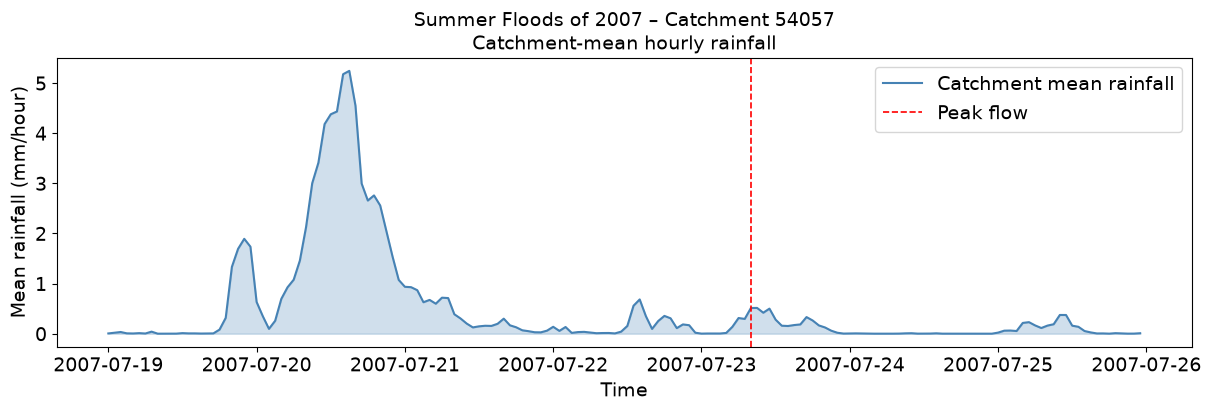

In [50]:
# Plotting a time series of catchment-mean rainfall

mean_rain = catchment_mean_rainfall(values, mask_2d) # Calculates the spatial mean of rainfall over the catchment at every time step, excluding pixels outside the catchment (NaN in mask_2d).
#The result is a 1-D array of length T (the number of time steps), containing the mean rainfall over the catchment at each time step.
times     = flat_df['time'].to_numpy() # Creates a 1-D array of timestamps corresponding to each time step in the flat_df DataFrame, which contains the flattened rainfall field data. 
# This array will be used for plotting the mean rainfall over time.

peak_flow_time = pd.Timestamp(event_meta['peak_flow']) # Creates a pandas Timestamp object from the peak flow time string in the event metadata, 
# which will be used to mark the peak flow time on the plot.

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.plot(times, mean_rain, color='steelblue', linewidth=1.5, label='Catchment mean rainfall')
ax.axvline(peak_flow_time, color='red', linestyle='--', linewidth=1.2, label='Peak flow')
ax.fill_between(times, mean_rain, alpha=0.25, color='steelblue')
ax.set_xlabel('Time')
ax.set_ylabel('Mean rainfall (mm/hour)')
ax.set_title(
    f'{event_meta["event_name"]} – Catchment {event_meta["catchment_id"]}\n'
    f'Catchment-mean hourly rainfall'
)
ax.legend()
plt.show()

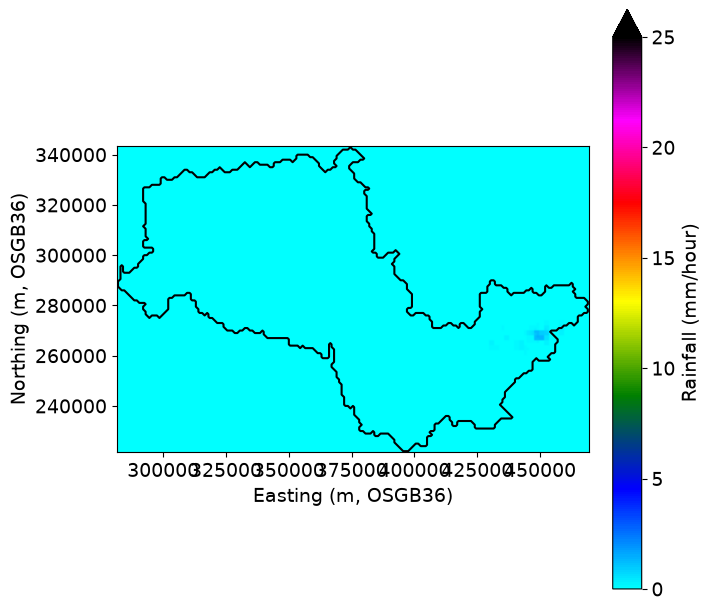

In [51]:
# ── Animation controls ────────────────────────────────────────────────────────
ANIM_EVENT_IDX = SELECTED_EVENT_IDX   # use the same event as above, or change
ANIM_INTERVAL  = 1000                  # ms per frame
ANIM_DPI       = 80                   # lower = smaller file
ANIM_VMAX      = VMAX
# ─────────────────────────────────────────────────────────────────────────────

anim_meta = EVENTS[ANIM_EVENT_IDX]
anim_eid  = anim_meta['event_id']

if anim_eid not in ready_events:
    raise FileNotFoundError(f'CSV files for "{anim_eid}" not found in {DATA_DIR}.')

flat_df_a, values_a, mask_a, northings_a, eastings_a = load_event_data(anim_eid, DATA_DIR)

fig_a, ax_a = plt.subplots(figsize=(7, 6), constrained_layout=True)
im_a = ax_a.imshow(
    values_a[0],
    origin='upper',
    extent=[eastings_a.min(), eastings_a.max(),
            northings_a.min(), northings_a.max()],
    cmap=CMAP, vmin=0, vmax=ANIM_VMAX, aspect='equal',
)
draw_catchment_outline(ax_a, mask_a, eastings_a, northings_a)
fig_a.colorbar(im_a, ax=ax_a, label='Rainfall (mm/hour)', extend='max')
ax_a.set_xlabel('Easting (m, OSGB36)')
ax_a.set_ylabel('Northing (m, OSGB36)')
title_a = ax_a.set_title('')

def _update(frame_idx: int):
    frame = values_a[frame_idx]
    im_a.set_data(frame)
    step_t = flat_df_a.loc[frame_idx, 'time']
    title_a.set_text(
        f'{anim_meta["event_name"]} – Catchment {anim_meta["catchment_id"]}\n'
        f'{step_t} | max = {np.nanmax(frame):.2f} mm/h'
    )
    return (im_a, title_a)

# ani = animation.FuncAnimation(
#     fig_a, _update,
#     frames=values_a.shape[0],
#     interval=ANIM_INTERVAL,
#     blit=False,
# )

# # Try MP4 first (needs ffmpeg), fall back to GIF
# out_mp4 = mp4_dir / f'{anim_eid}.mp4'
# out_gif = mp4_dir / f'{anim_eid}.gif'

# if shutil.which('ffmpeg'):
#     ani.save(str(out_mp4), writer='ffmpeg', dpi=ANIM_DPI)
#     plt.close(fig_a)
#     print(f'MP4 saved → {out_mp4}')
#     # Display using HTML5 video in Colab
#     from IPython.display import HTML
#     import base64
#     video_b64 = base64.b64encode(out_mp4.read_bytes()).decode()
#     display(HTML(f'<video controls width="640">'
#                  f'<source src="data:video/mp4;base64,{video_b64}" type="video/mp4">'
#                  f'</video>'))
# else:
#     ani.save(str(out_gif), writer='pillow', dpi=ANIM_DPI)
#     plt.close(fig_a)
#     print(f'GIF saved → {out_gif}')
#     display(Image(filename=str(out_gif)))

In [52]:
# Examining the shape of the rainfall data:
rain_01 = pd.read_csv(rain_dir / '01_summer_floods_of_2007_54057.csv')
print(f'Rainfall data shape for event 01: {rain_01.shape}')
print(rain_01.head())
print(rain_01['time'].dtypes)

Rainfall data shape for event 01: (168, 3)
   catchment_id                 time  rainfall (mm)
0         54057  2007-07-19 00:00:00       0.005083
1         54057  2007-07-19 01:00:00       0.020101
2         54057  2007-07-19 02:00:00       0.033527
3         54057  2007-07-19 03:00:00       0.006869
4         54057  2007-07-19 04:00:00       0.004428
str


In [53]:
# Converting the time column to DT format:
rain_01['time'] = pd.to_datetime(rain_01['time'], format='%Y-%m-%d %H:%M:%S')
print(rain_01['time'].dtypes)

datetime64[us]


In [54]:
rain_01_mean = rain_01.iloc[:, 2].mean(axis = 0)
rain_01_sd = rain_01.iloc[:, 2].std(axis = 0)
rain_01_max = rain_01.iloc[:, 2].max(axis = 0)
print(f"mean: {rain_01_mean :.3f}")
print(f"std: {rain_01_sd :.3f}")
print(f"max: {rain_01_max :.3f}")

mean: 0.502
std: 1.031
max: 5.244


In [55]:
# Examining the shape of the rainfall data:
river_01 = pd.read_csv(river_dir / '01_054057.csv')
print(f'River gauge data shape for event 01: {river_01.shape}')
print(river_01.head())
print(river_01['datetime'].dtypes)

River gauge data shape for event 01: (1692420, 4)
              datetime   value  resolution  flag
0  1975-09-25 15:00:00  27.150         NaN   0.0
1  1975-09-25 15:15:00  26.478        15.0   0.0
2  1975-09-25 15:30:00  25.750        15.0   0.0
3  1975-09-25 15:45:00  25.099        15.0   0.0
4  1975-09-25 16:00:00  24.648        15.0   0.0
str


In [56]:
# Converting the time column to DT format:
river_01['datetime'] = pd.to_datetime(river_01['datetime'], format='%Y-%m-%d %H:%M:%S')
print(river_01['datetime'].dtypes)

datetime64[us]


In [57]:
river_01_mean = river_01.iloc[:, 1].mean(axis = 0)
river_01_sd = river_01.iloc[:, 1].std(axis = 0)
river_01_max = river_01.iloc[:, 1].max(axis = 0)
print(f"mean: {river_01_mean :.3f}")
print(f"std: {river_01_sd :.3f}")
print(f"max: {river_01_max :.3f}")

mean: 112.884
std: 115.883
max: 1399.117


In [58]:
rain_start = rain_01['time'].min()
rain_end = rain_01['time'].max()
print(rain_start, rain_end)

2007-07-19 00:00:00 2007-07-25 23:00:00


In [59]:
one_wk_earlier = rain_start - pd.Timedelta(days=7)
three_wk_later = rain_end + pd.Timedelta(days=21)

In [60]:
rain_len = rain_end - rain_start
rain_len = rain_len.round('D')
rain_bins = rain_len.days
rain_bins = rain_bins * 4

print(f"No bins for rainfall event: {rain_bins}")

No bins for rainfall event: 28


In [61]:
# filtering the river gauge data to be similar to the rainfall data
filt_river_01 = river_01[river_01['datetime'] > one_wk_earlier]
filt_river_01 = filt_river_01[filt_river_01['datetime'] < three_wk_later]

print(filt_river_01['datetime'].min(), filt_river_01['datetime'].max())

2007-07-12 00:15:00 2007-08-15 22:45:00


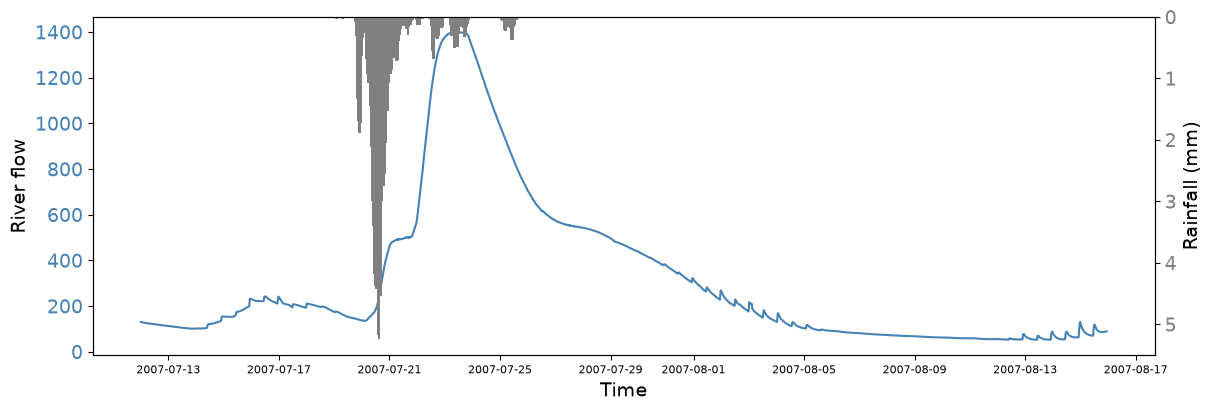

In [62]:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# Plotting the river flow data
ax.plot(filt_river_01['datetime'], filt_river_01['value'], color='steelblue')
ax.set_ylabel('River flow')
ax.tick_params(axis = 'y', labelcolor = 'steelblue') 

# Plotting the rainfall data
ax2 = ax.twinx()
ax2.bar(rain_01['time'], rain_01['rainfall (mm)'], width=0.1, color='grey')
ax2.set_ylabel('Rainfall (mm)')
ax2.invert_yaxis()  # Invert the y-axis for rainfall to show higher values at the top
ax2.tick_params(axis ='y', labelcolor = 'grey') 

ax.set_xlabel('Time')
ax.tick_params(axis='x', labelsize=8)

In [63]:
# Q1: How concentrated was the rainfall in time?
# Peak recorded rainfall intensity:
print(f"Peak rainfall intensity: {rain_01['rainfall (mm)'].max()} mm/hr \n")

# What was the maximum 4-hour rainfall accumulation?
rain_01['rolling_4h'] = rain_01['rainfall (mm)'].rolling(window=4, min_periods=1).sum()
max_index = rain_01['rolling_4h'].idxmax()
max_4hr_rainfall = rain_01['rolling_4h'].max()
print(f'Max 4 hour rainfall accumulation was {max_4hr_rainfall :.3f}mm at index no {max_index} \n')

# Total Daily rainfall:
daily_rainfall = rain_01.groupby(rain_01['time'].dt.date)['rainfall (mm)'].sum()
print("Total daily rainfall (mm):", daily_rainfall, '\n')

# How long did it take 50% and 80% of the total rainfall to occur?
# total rainfall overall:
total_rain = rain_01['rainfall (mm)'].sum()
# 50% & 80%:
fifty = total_rain * 0.5
eighty = total_rain * 0.8

# Cumulatively adding up the rainfall:
rain_01['cumul_rain']=rain_01['rainfall (mm)'].cumsum(skipna= True)
print(rain_01.head(), '\n')
    
# Identifying which row in the dataset has this value first. 
# 50%
for i, row in rain_01.iterrows():
    if row['cumul_rain'] >= fifty:
        print(f"Earliest recorded time with minimum 50% of rainfall: \n {row['time']}")
        print(f"Index for this row: {i}")
        delta_t_50 = row['time'] - rain_start
        print(f"Time passed to reach 50%: {delta_t_50} \n")
        break

# 80%
for i, row in rain_01.iterrows():
    if row['cumul_rain'] >= eighty:
        print(f"Earliest recorded time with minimum 80% of rainfall: \n {row['time']}")
        print(f"Index for this row: {i}")
        delta_t_80 = row['time'] - rain_start
        print(f"Time passed to reach 80%: {delta_t_80}")
        break

Peak rainfall intensity: 5.243605 mm/hr 

Max 4 hour rainfall accumulation was 19.403mm at index no 40 

Total daily rainfall (mm): time
2007-07-19     7.214576
2007-07-20    57.619000
2007-07-21     8.568189
2007-07-22     3.761886
2007-07-23     4.630181
2007-07-24     0.050126
2007-07-25     2.432465
Name: rainfall (mm), dtype: float64 

   catchment_id                time  rainfall (mm)  rolling_4h  cumul_rain
0         54057 2007-07-19 00:00:00       0.005083    0.005083    0.005083
1         54057 2007-07-19 01:00:00       0.020101    0.025184    0.025184
2         54057 2007-07-19 02:00:00       0.033527    0.058711    0.058711
3         54057 2007-07-19 03:00:00       0.006869    0.065580    0.065580
4         54057 2007-07-19 04:00:00       0.004428    0.064925    0.070008 

Earliest recorded time with minimum 50% of rainfall: 
 2007-07-20 15:00:00
Index for this row: 39
Time passed to reach 50%: 1 days 15:00:00 

Earliest recorded time with minimum 80% of rainfall: 
 2007-07-

In [64]:
# Q2: How quickly did the catchment respond to the rainfall?

# Lag between peak rainfall and peak river flow?
rain_max_i = rain_01['rainfall (mm)'].idxmax()
rain_max_t = rain_01['time'][rain_max_i]

river_max_i = river_01['value'].idxmax()
river_max_t = river_01['datetime'][river_max_i]

lag = river_max_t - rain_max_t
print(f"Lag between rainfall and riverflow max: {lag}")

# Time from the beginning of the rainfall to the beginning of the flood response: 
# immediate, delayed, gradual...?
rain_start = rain_01['time'][0]



Lag between rainfall and riverflow max: 2 days 17:00:00


Writing the functions up with fixed thresholds and sensitivity parameters:

In [65]:
# Trying to write code/ functions to compute this:
import numpy as np
import pandas as pd

# Calculating the variance across a moving window to identify where there is a sudden
# increase in variance, and therefore where there might be the start of a flood event
# this returns a variance series which is put into the next function along
def moving_variance(Q, window):
    return Q.rolling(window= window, min_periods = 1).var()

# Determine the flood threshold (fth) over which the variance must exceed for it to be counted as a 
# flood event, rather than just background flood flow
# the threshold in fischer et al., 2021 is defined as the mean of the moving variances + 0.25 *
# the standard deviation of these variances
def compute_fth(var_series):
    mean_var = var_series.mean()
    std_var = var_series.std()
    return mean_var + 2.5 * std_var # threshold raised to 1.0 * std_var, so it only detects stronger variability signals


# Identify the flood event by taking in a series/ column from a dataframe containing the discharge flow
def find_events(Q, dvar=7): #dvar = 5 = stops the variance reacting too much to tiny wiggles
    # Convert the flow into a series
    Q = pd.Series(Q).reset_index(drop=True) 
    Q = Q.rolling(window = 3, center= True).mean().bfill().ffill()
    # This smooths the discharge right after converting to a series, to remove any noise nad stop variance from flickering too much

    # Lag-1 differences
    QD = Q.diff() # Produces a new DF calld QD (i.e chanage in discharge) which contains the
                    # difference between each row and the row before in the discharge df
    QD.iloc[0] = 0 # This sets the very first difference as 0 (as there has been no diff yet)

    # Moving variance
    var_series = moving_variance(Q, dvar) # returns a variance series containing the moving variances

    # Threshold
    threshold = compute_fth(var_series) # coputing the threshold based on this variance series

    # Active points
    active = var_series > threshold # identifies where the flood events start, as per our criteria
                                    # returning a series (of same length as the discharge series)
                                    # of bool values (True = active event! False = not an event)
    events = [] # sets up an empty list to store results, where results will each be stored as a dictionary
    i = 0 # start index = 0
    n = len(Q) # n is the length of the event's dataframe (i.e. the total number of timesteps)

    # this whole looping logic is looping through the whole timeseries and extracting one flood event at a time
    while i < n: # while we haven't cycled though the whole event yet...
        # Detect if we are inside a flood event:
        if active.iloc[i] and QD.iloc[i] > 0:# and Q.iloc[i] > 0.3 * Q.max(): # Look at the current row/ index in the 'active' series. 
                            # if this index is True, it'll enter this loop. If it isn't True,
                            # it will move onto the next time slice and see whether that one is True
            # Find start
            start = i # initial index for the start of the event. This is shifted backwards in time by this:
            # flow_threshold = Q.quantile(0.25)
            while start > 0 and QD.iloc[start] >0 : # while we aren't at the beginning of the dataset                                                 # AND the flow is still increasing ...
                start -= 1 #... hop back to the previous row to check whether this is still increasing.
                # this loop is expandingthe event backwards through time to capture the full rising limb
                # = overall, this only allows forward movement through time if the variance stays above the threshold    
                # it will stop increasing once the flow no longer increases, or once we reach teh start of the dataset
            
            # Ignore events after main peak decay
            if start > Q.idxmax() + 200:
                i += 1
                continue

            end_temp = i # Find temporary end OF THE HIGH VARIANCE REGION (which we take as what was the initial start)
            while end_temp < n and active.iloc[end_temp]: # while we are still between the rising limb and 
                                                        # and the temporary end 
                end_temp += 1

            # Identify the Peak of the flow:
            search_end = min(end_temp + int(5 * (end_temp - start)), n)

            peak_idx = Q.iloc[start:search_end].idxmax()  # find the maximum discharge value
            # ... calculate the max discharge volume in the rising limb
            # this sums the volume of water across the rising limb = ~ the sum discharge between the start to the peak
            # ("search for a peak value within a region where we are confident there is something "event like" happening")
            # (this isn't even the full event, but rather just the active core of the event that we are looking at currently)
            if (peak_idx - start) < 10: # if this rising limb is too short (i.e. shorter than 150 minutes = ~ 2hours), ignore the event and move
                i += 1
                continue

            # -- only real events should reach this point -- #

            # End using volume balance
            rising_vol = Q.iloc[start:peak_idx].sum() # Calculate the volume of water discharged between the start of the event and the event peak
            cumulative = 0
            end = peak_idx # this is a safe default initialisation of the end index. i.e. “If we can’t find a better end, at least we have the peak”

            # Identifying the end of the event
            for j in range(peak_idx + 1, n): # start at the peak's index & move foward through time for the duration of the rest of the series
                cumulative += Q.iloc[j] # add that flow value to the cumulative (i.e. falling limb integral)
                if cumulative >= rising_vol and Q.iloc[j] < 0.15 * Q.iloc[peak_idx]:# Repeat this until the descending limb vol equals or exceeds the rising limb vol...
                                                                                    #AND until the discharge is less than 15% of the peak flow.
                    end = j # then identify at which index this value is achieved...
                    break # and end the loop

            if (end - start) >= 5: # this removes events that are smaller than 5 hours long, which are fake events probably
                events.append({ # add the indices to the events list of dictionaries
                "start": start,
                "peak": peak_idx,
                "end": end
            })

            i = end + 1 # Once the start, peak and end are found, it doesn't go onto the next row from the start row,
                        # but instead jumps straight to the index after the end of the event, so it can't double/ triple etc. count the same event!
        else:
            i += 1 # and if the current point isn't active, move onto the next one to check that one. 
        
        events_df = pd.DataFrame(events)
        
        # Events are merged post-processing to convert many tiny flood signals into one comprehensive flood signal
        if len(events_df) > 1:
            merged = [events_df.iloc[0].to_dict()] # this is the first detected event...

            for _, row in events_df.iloc[1:].iterrows(): #each subsequent flood event is then looked at...
                prev = merged[-1] # the current event and previous merged event are compared

                # the time gap between the events is checked. If the gap is small enough, they are close enough to be the same flood event
                if row['start'] - prev['end'] <= 5:
                    prev['end'] = row['end'] # this extends the end of the event to cover both events
                    prev['peak'] = max(prev['peak'], row['peak']) # this updates the peak so the peak is still the highest value
                else:
                    merged.append(row.to_dict()) # but they are kept as separate events if they aren't close to each other. 

            events_df = pd.DataFrame(merged)


    return events_df


Writing up the functions with the fixed parameters as defaults, but with the opportunity to tune it as per the individual catchment

In [66]:
# Trying to write code/ functions to compute this:
import numpy as np
import pandas as pd

# Calculating the variance across a moving window to identify where there is a sudden
# increase in variance, and therefore where there might be the start of a flood event
# this returns a variance series which is put into the next function along
def moving_variance(Q, window):
    return Q.rolling(window= window, min_periods = 1).var()

# Determine the flood threshold (fth) over which the variance must exceed for it to be counted as a 
# flood event, rather than just background flood flow
# the threshold in fischer et al., 2021 is defined as the mean of the moving variances + 0.25 *
# the standard deviation of these variances
def compute_fth(var_series, std_var_multiple = 2.5):
    mean_var = var_series.mean()
    std_var = var_series.std()
    return mean_var + std_var_multiple * std_var # threshold raised to 2.5 * std_var, so it only detects stronger variability signals


# Identify the flood event by taking in a series/ column from a dataframe containing the discharge flow
def find_events(Q, dvar=7, peak_flow_multiple = 5, time_slice_multiple = 10, end_idx_multiple = 0.15, min_time_slices = 5, flood_closeness_time_slices = 5): #dvar = 5 = stops the variance reacting too much to tiny wiggles
    
    """
    Q : discharge flow series
    dvar : ___
    peak_flow_multiple : defines how many time slices into the future, relative to the length of the ascending arm,
    should be searched for the peak threshold. Default is 5 * the length of the ascending arm
    time_slice_multiple : defines how short a flood rising event is before it is discarded as too short to be a true
    flood event. Default is 10 time slices (corresponding to discharge increaes for durations of 150 minutes in 15 min
    temporal resolution data). This should vary depending on the temporal resolution of the data.
    end_idx_multiple : defines how low the discharge volume should be, relative to the peak flow, to help determine the end
    of the flood event (one of two criteria). Default is 0.15 (i.e. flow should be 15% of the peak flow) but this can be varied
    depending on the catchment
    min_time_slices : defines how many time slices long theevent must be to be discarded as not a real event. Here, default is 5,
    so with a 15 min temporal resolution dataset flood events with rising limbs shorter than 75min long aren't counted as true
    flood events, to prevent false identification of many flood events
    flood_closeness_time_slices : if more than one peak is identified, this defines how much time can pass before they are treated
    as separate events, or until they are merged. The default here is 5 time slices, so if less than 75 mins (5 * 15 min res) passes 
    between two separate flood peaks, they are merged into the same flood event. 
    """
    # Convert the flow into a series
    Q = pd.Series(Q).reset_index(drop=True) 
    Q = Q.rolling(window = 3, center= True).mean().bfill().ffill()
    # This smooths the discharge right after converting to a series, to remove any noise nad stop variance from flickering too much

    # Lag-1 differences
    QD = Q.diff() # Produces a new DF calld QD (i.e chanage in discharge) which contains the
                    # difference between each row and the row before in the discharge df
    QD.iloc[0] = 0 # This sets the very first difference as 0 (as there has been no diff yet)

    # Moving variance
    var_series = moving_variance(Q, dvar) # returns a variance series containing the moving variances

    # Threshold
    threshold = compute_fth(var_series) # coputing the threshold based on this variance series

    # Active points
    active = var_series > threshold # identifies where the flood events start, as per our criteria
                                    # returning a series (of same length as the discharge series)
                                    # of bool values (True = active event! False = not an event)
    events = [] # sets up an empty list to store results, where results will each be stored as a dictionary
    i = 0 # start index = 0
    n = len(Q) # n is the length of the event's dataframe (i.e. the total number of timesteps)

    # this whole looping logic is looping through the whole timeseries and extracting one flood event at a time
    while i < n: # while we haven't cycled though the whole event yet...
        # Detect if we are inside a flood event:
        if active.iloc[i] and QD.iloc[i] > 0:# and Q.iloc[i] > 0.3 * Q.max(): # Look at the current row/ index in the 'active' series. 
                            # if this index is True, it'll enter this loop. If it isn't True,
                            # it will move onto the next time slice and see whether that one is True
            # Find start
            start = i # initial index for the start of the event. This is shifted backwards in time by this:
            # flow_threshold = Q.quantile(0.25)
            while start > 0 and QD.iloc[start] >0 : # while we aren't at the beginning of the dataset                                                 # AND the flow is still increasing ...
                start -= 1 #... hop back to the previous row to check whether this is still increasing.
                # this loop is expandingthe event backwards through time to capture the full rising limb
                # = overall, this only allows forward movement through time if the variance stays above the threshold    
                # it will stop increasing once the flow no longer increases, or once we reach teh start of the dataset
            
            # Ignore events after main peak decay
            if start > Q.idxmax() + 200:
                i += 1
                continue

            end_temp = i # Find temporary end OF THE HIGH VARIANCE REGION (which we take as what was the initial start)
            while end_temp < n and active.iloc[end_temp]: # while we are still between the rising limb and 
                                                        # and the temporary end 
                end_temp += 1

            # Identify the Peak of the flow:
            search_end = min(end_temp + int(peak_flow_multiple * (end_temp - start)), n)

            peak_idx = Q.iloc[start:search_end].idxmax()  # find the maximum discharge value
            # ... calculate the max discharge volume in the rising limb
            # this sums the volume of water across the rising limb = ~ the sum discharge between the start to the peak
            # ("search for a peak value within a region where we are confident there is something "event like" happening")
            # (this isn't even the full event, but rather just the active core of the event that we are looking at currently)
            if (peak_idx - start) < time_slice_multiple: # if this rising limb is too short (i.e. shorter than 150 minutes = ~ 2hours), ignore the event and move
                i += 1
                continue

            # -- only real events should reach this point -- #

            # End using volume balance
            rising_vol = Q.iloc[start:peak_idx].sum() # Calculate the volume of water discharged between the start of the event and the event peak
            cumulative = 0
            end = peak_idx # this is a safe default initialisation of the end index. i.e. “If we can’t find a better end, at least we have the peak”

            # Identifying the end of the event
            for j in range(peak_idx + 1, n): # start at the peak's index & move foward through time for the duration of the rest of the series
                cumulative += Q.iloc[j] # add that flow value to the cumulative (i.e. falling limb integral)
                if cumulative >= rising_vol and Q.iloc[j] < end_idx_multiple * Q.iloc[peak_idx]:# Repeat this until the descending limb vol equals or exceeds the rising limb vol...
                                                                                    #AND until the discharge is less than 15% of the peak flow.
                    end = j # then identify at which index this value is achieved...
                    break # and end the loop

            if (end - start) >= min_time_slices: # this removes events that are smaller than 5 * temp res (i.e. 75 min long), which are fake events probably
                events.append({ # add the indices to the events list of dictionaries
                "start": start,
                "peak": peak_idx,
                "end": end
            })

            i = end + 1 # Once the start, peak and end are found, it doesn't go onto the next row from the start row,
                        # but instead jumps straight to the index after the end of the event, so it can't double/ triple etc. count the same event!
        else:
            i += 1 # and if the current point isn't active, move onto the next one to check that one. 
        
        events_df = pd.DataFrame(events)
        
        # Events are merged post-processing to convert many tiny flood signals into one comprehensive flood signal
        if len(events_df) > 1:
            merged = [events_df.iloc[0].to_dict()] # this is the first detected event...

            for _, row in events_df.iloc[1:].iterrows(): #each subsequent flood event is then looked at...
                prev = merged[-1] # the current event and previous merged event are compared

                # the time gap between the events is checked. If the gap is small enough, they are close enough to be the same flood event
                if row['start'] - prev['end'] <= flood_closeness_time_slices:
                    prev['end'] = row['end'] # this extends the end of the event to cover both events
                    prev['peak'] = max(prev['peak'], row['peak']) # this updates the peak so the peak is still the highest value
                else:
                    merged.append(row.to_dict()) # but they are kept as separate events if they aren't close to each other. 

            events_df = pd.DataFrame(merged)


    return events_df


In [67]:
print(filt_river_01.shape)

(3355, 4)


In [68]:
# Separating out the base from the flood flow using the statistical method developed by Fischer et al., 2021:
filt_flood01_i = find_events(filt_river_01['value'])
print(filt_flood01_i)

   start  peak   end
0    778  1088  2050


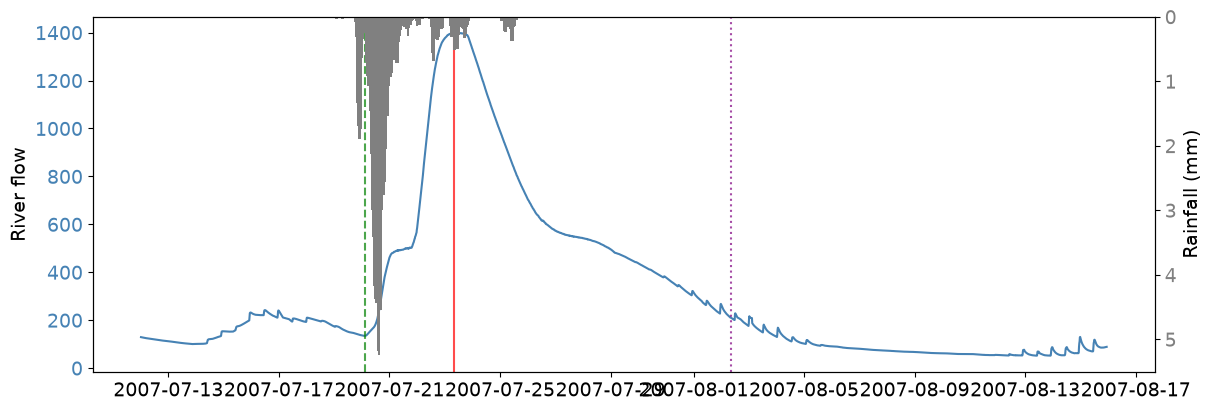

In [69]:
# Trying to see where these are:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# --- River flow ---
ax.plot(filt_river_01['datetime'], filt_river_01['value'], color='steelblue')
ax.set_ylabel('River flow')
ax.tick_params(axis='y', labelcolor='steelblue')

# --- Rainfall ---
ax2 = ax.twinx()
ax2.bar(rain_01['time'], rain_01['rainfall (mm)'], width=0.1, color='grey')
ax2.set_ylabel('Rainfall (mm)')
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelcolor='grey')

# --- ADD EVENT LINES HERE ---
for _, row in filt_flood01_i.iterrows():
    
    # Convert indices → timestamps
    start_time = filt_river_01['datetime'].iloc[row['start']]
    peak_time  = filt_river_01['datetime'].iloc[row['peak']]
    end_time   = filt_river_01['datetime'].iloc[row['end']]
    
    # Plot vertical lines
    ax.axvline(start_time, color='green', linestyle='--', alpha=0.7, label='Start')
    ax.axvline(peak_time,  color='red', linestyle='-', alpha=0.7, label='Peak')
    ax.axvline(end_time,   color='purple', linestyle=':', alpha=0.7, label='End')

# --- Avoid duplicate legend entries ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))


In [70]:
# Identifying the start of the flood event:
start_time = filt_river_01['datetime'].iloc[row['start']]

# Finding the difference between the onset of the rainfall and the onset of the flood event:
D_onset = start_time - rain_start
print(D_onset)

1 days 02:45:00


In [71]:
# Q3: How quickly did the flood develop?
# Steepest 15 min increase in river flow
river_01['rate_of_rise'] = river_01['value'].diff()
max_ror = river_01['rate_of_rise'].max()
max_ror_idx = river_01['rate_of_rise'].idxmax()
max_ror_time = river_01.loc[max_ror_idx, 'datetime']
print(f'Max ROR: {max_ror} m3/s, Max ROR time: {max_ror_time}')

# How long did it take to rise from the start of the flood to the peak?
peak_time = filt_river_01['datetime'].iloc[row['peak']]
D_peak = peak_time - start_time
print(f"Time for peak of flood, from onset of the flood event: {D_peak}")



Max ROR: 108.0 m3/s, Max ROR time: 2001-03-22 13:30:00
Time for peak of flood, from onset of the flood event: 3 days 05:30:00


# **Morpeth floods 2008 Analysis**

In [72]:
# ── User controls ─────────────────────────────────────────────────────────────
SELECTED_EVENT_IDX = 1    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
STEP_INDEX         = 5    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range

print(f'Event      : {event_meta["event_name"]} ({event_id})')
print(f'Catchment  : {event_meta["catchment_id"]}')
print(f'Period     : {event_meta["start_time"]} → {event_meta["end_time"]}')
print(f'Time steps : {n_steps}')
print(f'Grid shape : {values.shape[1]} northings × {values.shape[2]} eastings')
# print(f'Plotting step {STEP_INDEX} of {n_steps - 1} …')

Event      : Morpeth Flood 2008 (02_morpeth_flood_2008_22007)
Catchment  : 22007
Period     : 2008-09-05 → 2008-09-08 23:00:00
Time steps : 92
Grid shape : 21 northings × 29 eastings


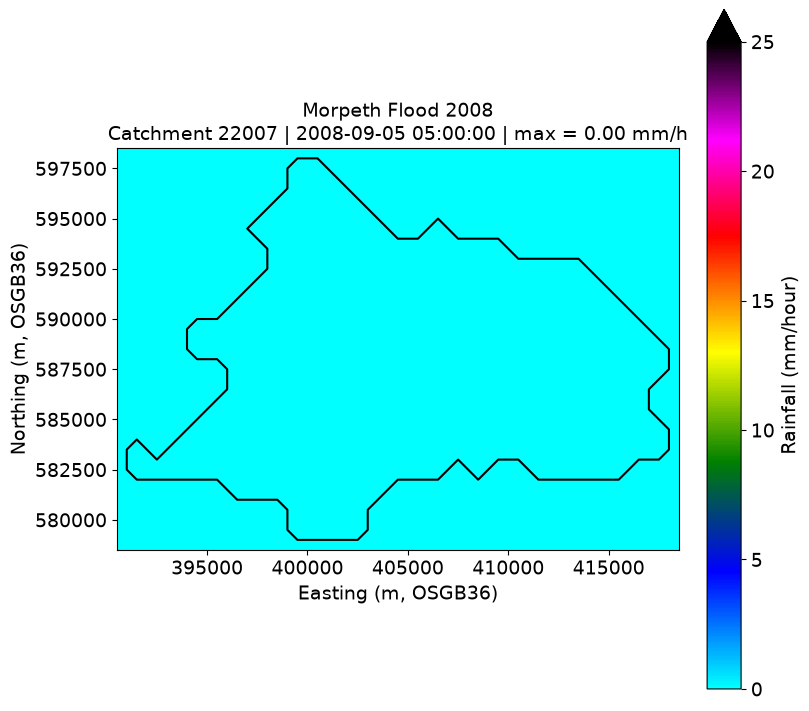

In [73]:
# ── Single time-step map ───────────────────────────────────────────────────────
rainfall_step = values[STEP_INDEX] # Extracts the rainfall values for the selected time step (STEP_INDEX) from the 3D rainfall values array (values), resulting in a 2D array of shape (n_north, n_east) representing the rainfall at that specific time step.
step_time     = flat_df.loc[STEP_INDEX, 'time'] # Extracts the timestamp for the selected time step (STEP_INDEX) from the flat_df DataFrame, which contains the flattened rainfall field data. This timestamp corresponds to the specific time at which the rainfall values in rainfall_step were recorded.
step_max      = np.nanmax(rainfall_step) # Finds the maximum rainfall value in the 2D array rainfall_step, ignoring any NaN values, and stores it in step_max.

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

im = ax.imshow(
    rainfall_step,
    origin='upper',
    extent=[eastings.min(), eastings.max(), northings.min(), northings.max()],
    cmap=CMAP,
    vmin=0,
    vmax=VMAX,
    aspect='equal',
)
draw_catchment_outline(ax, mask_2d, eastings, northings)
fig.colorbar(im, ax=ax, label='Rainfall (mm/hour)', extend='max')

ax.set_xlabel('Easting (m, OSGB36)')
ax.set_ylabel('Northing (m, OSGB36)')
ax.set_title(
    f'{event_meta["event_name"]}\n'
    f'Catchment {event_meta["catchment_id"]} | '
    f'{step_time} | max = {step_max:.2f} mm/h'
)
plt.show()

# **Cumbria floods 2009 Analysis**

In [74]:
# ── User controls ─────────────────────────────────────────────────────────────
SELECTED_EVENT_IDX = 2    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
STEP_INDEX         = 90    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range

print(f'Event      : {event_meta["event_name"]} ({event_id})')
print(f'Catchment  : {event_meta["catchment_id"]}')
print(f'Period     : {event_meta["start_time"]} → {event_meta["end_time"]}')
print(f'Time steps : {n_steps}')
print(f'Grid shape : {values.shape[1]} northings × {values.shape[2]} eastings')
# print(f'Plotting step {STEP_INDEX} of {n_steps - 1} …')

Event      : Cumbria Floods of 2009 (03_cumbria_floods_of_2009_75002)
Catchment  : 75002
Period     : 2009-11-17 → 2009-11-20 23:00:00
Time steps : 96
Grid shape : 33 northings × 39 eastings


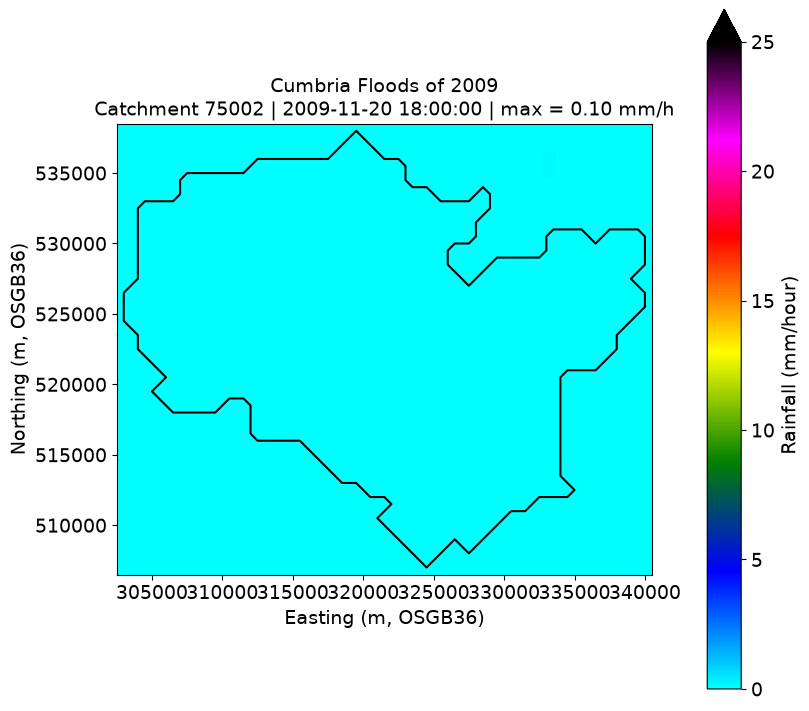

In [75]:
# ── Single time-step map ───────────────────────────────────────────────────────
rainfall_step = values[STEP_INDEX] # Extracts the rainfall values for the selected time step (STEP_INDEX) from the 3D rainfall values array (values), resulting in a 2D array of shape (n_north, n_east) representing the rainfall at that specific time step.
step_time     = flat_df.loc[STEP_INDEX, 'time'] # Extracts the timestamp for the selected time step (STEP_INDEX) from the flat_df DataFrame, which contains the flattened rainfall field data. This timestamp corresponds to the specific time at which the rainfall values in rainfall_step were recorded.
step_max      = np.nanmax(rainfall_step) # Finds the maximum rainfall value in the 2D array rainfall_step, ignoring any NaN values, and stores it in step_max.

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

im = ax.imshow(
    rainfall_step,
    origin='upper',
    extent=[eastings.min(), eastings.max(), northings.min(), northings.max()],
    cmap=CMAP,
    vmin=0,
    vmax=VMAX,
    aspect='equal',
)
draw_catchment_outline(ax, mask_2d, eastings, northings)
fig.colorbar(im, ax=ax, label='Rainfall (mm/hour)', extend='max')

ax.set_xlabel('Easting (m, OSGB36)')
ax.set_ylabel('Northing (m, OSGB36)')
ax.set_title(
    f'{event_meta["event_name"]}\n'
    f'Catchment {event_meta["catchment_id"]} | '
    f'{step_time} | max = {step_max:.2f} mm/h'
)
plt.show()

# **Storm Desmond floods 2015 Analysis**

In [76]:
# ── User controls ─────────────────────────────────────────────────────────────
SELECTED_EVENT_IDX = 3    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
STEP_INDEX         = 90    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range

print(f'Event      : {event_meta["event_name"]} ({event_id})')
print(f'Catchment  : {event_meta["catchment_id"]}')
print(f'Period     : {event_meta["start_time"]} → {event_meta["end_time"]}')
print(f'Time steps : {n_steps}')
print(f'Grid shape : {values.shape[1]} northings × {values.shape[2]} eastings')
# print(f'Plotting step {STEP_INDEX} of {n_steps - 1} …')

Event      : Storm Desmond 2015 (04_storm_desmond_2015_76007)
Catchment  : 76007
Period     : 2015-12-04 → 2015-12-08 23:00:00
Time steps : 120
Grid shape : 88 northings × 65 eastings


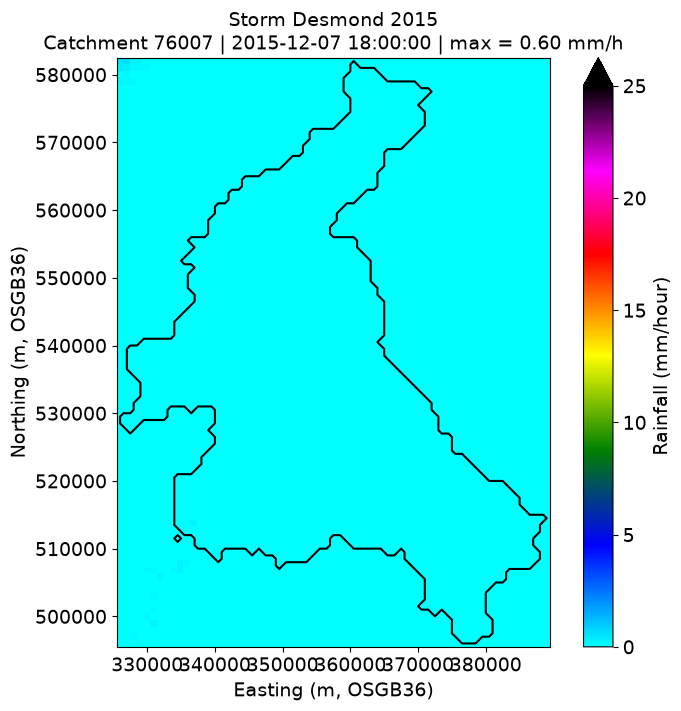

In [77]:
# ── Single time-step map ───────────────────────────────────────────────────────
rainfall_step = values[STEP_INDEX] # Extracts the rainfall values for the selected time step (STEP_INDEX) from the 3D rainfall values array (values), resulting in a 2D array of shape (n_north, n_east) representing the rainfall at that specific time step.
step_time     = flat_df.loc[STEP_INDEX, 'time'] # Extracts the timestamp for the selected time step (STEP_INDEX) from the flat_df DataFrame, which contains the flattened rainfall field data. This timestamp corresponds to the specific time at which the rainfall values in rainfall_step were recorded.
step_max      = np.nanmax(rainfall_step) # Finds the maximum rainfall value in the 2D array rainfall_step, ignoring any NaN values, and stores it in step_max.

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

im = ax.imshow(
    rainfall_step,
    origin='upper',
    extent=[eastings.min(), eastings.max(), northings.min(), northings.max()],
    cmap=CMAP,
    vmin=0,
    vmax=VMAX,
    aspect='equal',
)
draw_catchment_outline(ax, mask_2d, eastings, northings)
fig.colorbar(im, ax=ax, label='Rainfall (mm/hour)', extend='max')

ax.set_xlabel('Easting (m, OSGB36)')
ax.set_ylabel('Northing (m, OSGB36)')
ax.set_title(
    f'{event_meta["event_name"]}\n'
    f'Catchment {event_meta["catchment_id"]} | '
    f'{step_time} | max = {step_max:.2f} mm/h'
)
plt.show()

**Exploring the catchment boundaries data**

In [80]:
# ── User controls ─────────────────────────────────────────────────────────────
SELECTED_EVENT_IDX = 3    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
STEP_INDEX         = 90    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range

print(f'Event      : {event_meta["event_name"]} ({event_id})')
print(f'Catchment  : {event_meta["catchment_id"]}')
print(f'Period     : {event_meta["start_time"]} → {event_meta["end_time"]}')
print(f'Time steps : {n_steps}')
print(f'Grid shape : {values.shape[1]} northings × {values.shape[2]} eastings')
# print(f'Plotting step {STEP_INDEX} of {n_steps - 1} …')

Event      : Storm Desmond 2015 (04_storm_desmond_2015_76007)
Catchment  : 76007
Period     : 2015-12-04 → 2015-12-08 23:00:00
Time steps : 120
Grid shape : 88 northings × 65 eastings


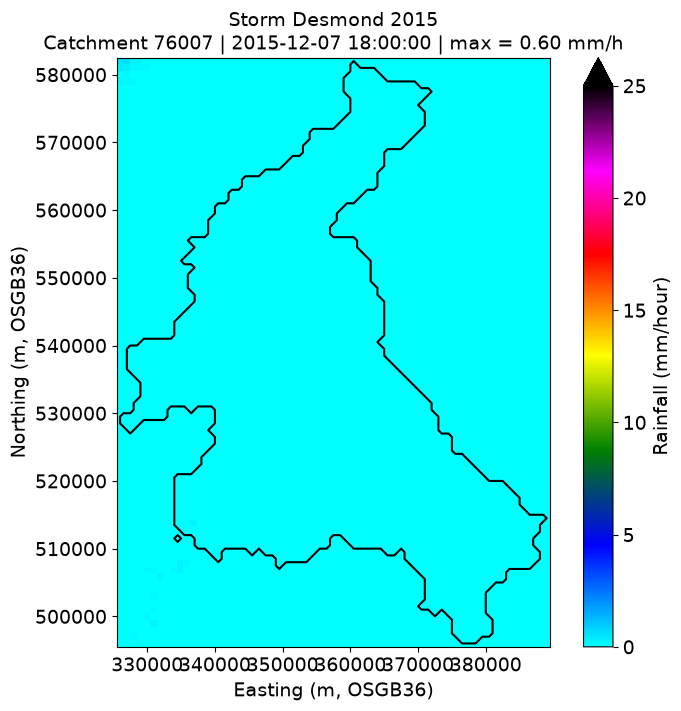

In [ ]:
# ── Single time-step map ───────────────────────────────────────────────────────
rainfall_step = values[STEP_INDEX] # Extracts the rainfall values for the selected time step (STEP_INDEX) from the 3D rainfall values array (values), resulting in a 2D array of shape (n_north, n_east) representing the rainfall at that specific time step.
step_time     = flat_df.loc[STEP_INDEX, 'time'] # Extracts the timestamp for the selected time step (STEP_INDEX) from the flat_df DataFrame, which contains the flattened rainfall field data. This timestamp corresponds to the specific time at which the rainfall values in rainfall_step were recorded.
step_max      = np.nanmax(rainfall_step) # Finds the maximum rainfall value in the 2D array rainfall_step, ignoring any NaN values, and stores it in step_max.

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

im = ax.imshow(
    rainfall_step,
    origin='upper',
    extent=[eastings.min(), eastings.max(), northings.min(), northings.max()], # fits the big box/ border to fit exactly around the catchment
    cmap=CMAP,
    vmin=0,
    vmax=VMAX,
    aspect='equal',
)
draw_catchment_outline(ax, mask_2d, eastings, northings) # A home-made function
fig.colorbar(im, ax=ax, label='Rainfall (mm/hour)', extend='max')

ax.set_xlabel('Easting (m, OSGB36)')
ax.set_ylabel('Northing (m, OSGB36)')
ax.set_title(
    f'{event_meta["event_name"]}\n'
    f'Catchment {event_meta["catchment_id"]} | '
    f'{step_time} | max = {step_max:.2f} mm/h'
)
plt.show()

# **Exploring EOF analysis**

In [82]:
# Loading in the rainfall data:
rain_04 = pd.read_csv(rain_dir / '04_storm_desmond_2015_76007.csv')

# Converting the time column to DT format:
rain_04['time'] = pd.to_datetime(rain_04['time'], format='%Y-%m-%d %H:%M:%S')
print(rain_04['time'].dtypes)

datetime64[us]


In [84]:
# Inspecting the data's shape etc.
print(rain_04.shape)
print(rain_04.head)

(120, 3)
<bound method NDFrame.head of      catchment_id                time  rainfall (mm)
0           76007 2015-12-04 00:00:00       0.008061
1           76007 2015-12-04 01:00:00       0.042204
2           76007 2015-12-04 02:00:00       0.001033
3           76007 2015-12-04 03:00:00       0.004497
4           76007 2015-12-04 04:00:00       0.032711
..            ...                 ...            ...
115         76007 2015-12-08 19:00:00       1.076001
116         76007 2015-12-08 20:00:00       0.480138
117         76007 2015-12-08 21:00:00       0.080087
118         76007 2015-12-08 22:00:00       0.001290
119         76007 2015-12-08 23:00:00       0.005246

[120 rows x 3 columns]>


In [85]:
# Getting the 3D rainfall data:
SELECTED_EVENT_IDX = 3    # 0 = Summer Floods 2007, 1 = Morpeth 2008, …
# STEP_INDEX         = 120    # time-step index within the event (0 = first hour)
VMAX               = 25   # colour-scale max (mm/hour)
# ─────────────────────────────────────────────────────────────────────────────

event_meta = EVENTS[SELECTED_EVENT_IDX] # Gets the meta data for this flood event
event_id   = event_meta['event_id'] # Gets the event ID for this flood event

if event_id not in ready_events: # Troubleshooting stuff
    raise FileNotFoundError(
        f'CSV files for "{event_id}" were not found in {DATA_DIR}.\n'
        'Upload them and re-run Section 3.'
    )

flat_df, values, mask_2d, northings, eastings = load_event_data(event_id, DATA_DIR) # Loads the flattened rainfall DataFrame (colnames: pixel_000000, pixel_000001, ...), the 3D rainfall values array (T, n_north, n_east), 
    # the 2D catchment mask (mask_2d, containing 1.0 for inside and NaN for outside), and the unique northing and easting coordinates (northings, eastings, as arrays).

n_steps = len(flat_df) # Gets the number of time steps in the flat_df DataFrame, which is the number of rows in the DataFrame
# STEP_INDEX = min(max(STEP_INDEX, 0), n_steps - 1) # Ensures the step index is within the valid range


In [ ]:
print(values.shape)
# 120 time steps, 88 lon vals, 65 lat vals

(120, 88, 65)


In [87]:
desmond_vals = values.copy()

In [ ]:
for ht in len(range(0, 121, 1)): #for the hour time (i.e every hour) for the length of this dataset...
    l = np.arange(ht, desmond_vals.shape[0],1)
    

In [ ]:
U, D, VT = np.linalg.svd()


In [ ]:
start = '08:15:00'
start = pd.to_datetime(start, format = '%H:%M:%S')
end = '16:35:00'
end = pd.to_datetime(end, format = '%H:%M:%S')

In [ ]:
diff = end - start
print(diff)

# **Experimenting with Rotating the Fields**

In [52]:
# Loading in the data
nrfa_df = pd.read_csv(nrfa_dir / "NRFA_Peak_Flow_dataset_14_w_coords.csv")
catchment_coords = nrfa_df[['Station', 'Easting', 'Northing', 'CEasting', 'CNorthing']]
print(catchment_coords.head)


<bound method NDFrame.head of      Station  Easting  Northing  CEasting  CNorthing
0       2001   299839    918163    284344     929781
1       2002   289156    903916    274454     916267
2       3002   249136    892152    240494     888016
3       3003   240305    900145    231272     901365
4       3004   247176    902133    239146     914664
..       ...      ...       ...       ...        ...
921   205101   331790    372370    330591     371140
922   206001   308536    331026    314605     330541
923   206006   335000    323100    333904     325199
924   236005   233195    335906    240998     344221
925   236007   220486    340003    211879     348444

[926 rows x 5 columns]>


In [ ]:
# Extracting the catchment events from the events dictionary
catch_ids = []
for dict in EVENTS:
    catch_ids.append(dict["catchment_id"])

# converting the ids to integers 
for i, id in enumerate(catch_ids):
    catch_ids[i] = int(id)

# Filtering out these catchments from the data set (I don't think they actually exist in there...)
catchment_coords = catchment_coords[
    catchment_coords['Station'].isin(catch_ids)
]

print(catchment_coords) 

print(catch_ids)

     Station  Easting  Northing  CEasting  CNorthing  ACW_rotation_required
126    22007   417458    585790    404914     587655             278.456598
156    25006   403361    512209    393998     510669             260.659778
619    54057   384491    227878    369150     284667             344.882930
803    75002   303700    530500    321059     523738             111.282832
816    76007   339000    557103    355831     534240             143.640703
[54057, 22007, 75002, 76007, 25006, 13008]


In [65]:
# Creating copies of this DF for exporting to google earth:
station_coords = catchment_coords[['Station', 'Easting', 'Northing']]
station_coords.to_csv('station_coords.csv', index=False)

centroid_coords = catchment_coords[['Station', 'CEasting', 'CNorthing']]
centroid_coords.to_csv('centroid_coords.csv', index=False)

In [39]:
print(station_coords, '\n')
print(centroid_coords)

     Station  Easting  Northing
126    22007   417458    585790
156    25006   403361    512209
619    54057   384491    227878
803    75002   303700    530500
816    76007   339000    557103 

     Station  CEasting  CNorthing
126    22007    404914     587655
156    25006    393998     510669
619    54057    369150     284667
803    75002    321059     523738
816    76007    355831     534240


In [ ]:
# Reprojecting the coordinate systems to  latitude/longitude (WGS84, EPSG:4326)
# Then exporting them

# # Station coordinates
# gdf = gpd.GeoDataFrame(
#     station_coords,
#     geometry=gpd.points_from_xy(
#         station_coords['Easting'],
#         station_coords['Northing']
#     ),
#     crs="EPSG:27700"
# )
# gdf = gdf.to_crs("EPSG:4326")
# station_coords["Longitude"] = gdf.geometry.x
# station_coords["Latitude"] = gdf.geometry.y
# gdf.to_file("station_coords.kml", driver = "KML")


# # Centroid coordinates
# gdf = gpd.GeoDataFrame(
#     centroid_coords,
#     geometry=gpd.points_from_xy(
#         centroid_coords['CEasting'],
#         centroid_coords['CNorthing']
#     ),
#     crs="EPSG:27700"
# )
# gdf = gdf.to_crs("EPSG:4326")
# centroid_coords["Longitude"] = gdf.geometry.x
# centroid_coords["Latitude"] = gdf.geometry.y
# gdf.to_file("centroid_coords.kml", driver = "KML")

In [56]:
print(catchment_coords)

     Station  Easting  Northing  CEasting  CNorthing
126    22007   417458    585790    404914     587655
156    25006   403361    512209    393998     510669
619    54057   384491    227878    369150     284667
803    75002   303700    530500    321059     523738
816    76007   339000    557103    355831     534240


In [9]:
# Creating a list of 'lines' between the centroid and the gauge outlet to determine the catchment orientation
centgauge_lines = []

for _, row in catchment_coords.iterrows():

    line = LineString([
        (row['CEasting'], row['CNorthing']),   # centroid
        (row['Easting'], row['Northing'])    # gauge
    ])
    centgauge_lines.append(line)

line_gdf = gpd.GeoDataFrame(
    catchment_coords[['Station']],
    geometry=centgauge_lines,
    crs="EPSG:27700"
)

In [10]:
#Creating a vertical axis for visualisation
a = LineString([[350000, 220000], [350000, 589000]])
a.length

x_vals = np.array([350000, 350000])
y_vals = np.array([220000,589000 ])

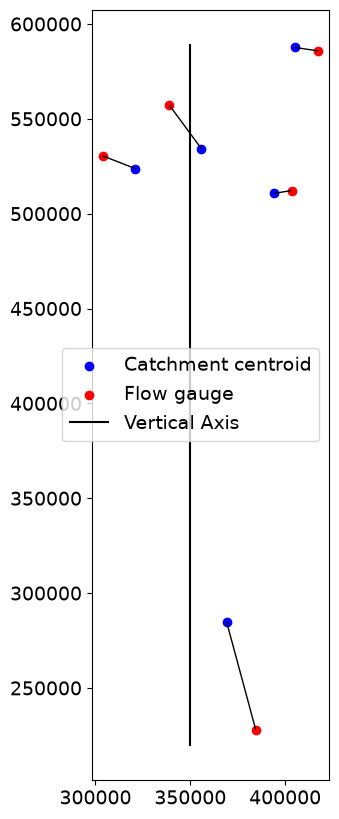

In [11]:
# Plotting these lines to confirm they are in the correct angle
fig, ax = plt.subplots(figsize=(10, 10))

# Plot lines
line_gdf.plot(ax=ax, color='black', linewidth=1)

# Plot centroids
ax.scatter(
    catchment_coords['CEasting'],
    catchment_coords['CNorthing'],
    c='blue',
    label='Catchment centroid'
)

# Plot gauges
ax.scatter(
    catchment_coords['Easting'],
    catchment_coords['Northing'],
    c='red',
    label='Flow gauge'
)

ax.plot(x_vals,y_vals, color = 'black', label = 'Vertical Axis')

ax.set_aspect('equal')
ax.legend()

plt.show()

In [66]:
# Calculating the change in x vs the change in y (i.e sort of like the gradient)
dx = catchment_coords['Easting'] - catchment_coords['CEasting']
dy = catchment_coords['Northing'] - catchment_coords['CNorthing']

# Calculate bearing from the vertical (= gives the clockwise angle from North)
bearing = np.degrees(np.arctan2(dx, dy))

# Adding these to the dataframe:
catchment_coords['ACW_rotation_required'] = bearing + 180
print(catchment_coords)

     Station  Easting  Northing  CEasting  CNorthing  ACW_rotation_required
126    22007   417458    585790    404914     587655             278.456598
156    25006   403361    512209    393998     510669             260.659778
619    54057   384491    227878    369150     284667             344.882930
803    75002   303700    530500    321059     523738             111.282832
816    76007   339000    557103    355831     534240             143.640703


In [67]:
# Rotate each catchment about its centroid
rot_centroid_x = []
rot_centroid_y = []

rot_gauge_x = []
rot_gauge_y = []

for _, row in catchment_coords.iterrows():

    theta = np.radians(row['ACW_rotation_required'])

    # Vector from centroid to gauge
    dx = row['Easting'] - row['CEasting']
    dy = row['Northing'] - row['CNorthing']

    # Rotate vector
    dx_rot = dx*np.cos(theta) - dy*np.sin(theta)
    dy_rot = dx*np.sin(theta) + dy*np.cos(theta)

    # Put centroid at origin
    rot_centroid_x.append(0)
    rot_centroid_y.append(0)

    rot_gauge_x.append(dx_rot)
    rot_gauge_y.append(dy_rot)


In [68]:
print("Maximum horizontal offset:",
      np.max(np.abs(rot_gauge_x)))

print("Number of gauges below centroid:",
      np.sum(np.array(rot_gauge_y) < 0),
      "out of",
      len(rot_gauge_y))

Maximum horizontal offset: 5.4569682106375694e-12
Number of gauges below centroid: 5 out of 5


In [69]:
# Creating a dictionary of dictionaries with this structure:

# catchment_rainfall_data = {

#     13008: {
#         'event_id': '06_strom_babeth_2023_13008',
#         'flat_df': <DataFrame>,
#         'values': <ndarray>,
#         'mask_2d': <ndarray>,
#         'northings': <ndarray>,
#         'eastings': <ndarray>,
#         'n_steps': 144
#     },

#     27009: {
#         'event_id': 'some_other_event',
#         'flat_df': <DataFrame>,
#         ...
#     }
# }

catchment_rainfall_data = {} # Creating a new dictionary to store all the dataframes in 

for id in catch_ids: # for each catchment/ station ID
    for event in EVENTS: # check through each of the events in the event dictionary

        if int(event['catchment_id']) == id: # if this station ID matches that in the dictionary...

            this_event_id = event['event_id'] # then get the event ID

            flat_df, values, mask_2d, northings, eastings = \
                load_event_data(this_event_id, DATA_DIR) # use this event ID to load the data for the event
            
            for i, row in catchment_coords.iterrows(): # check through the catchment coordinates df
                if row['Station'] == id: # and if the station ID matches this station ID
                    rot_angle = row['ACW_rotation_required'] # then get the rotation angle for this location
                    
            catchment_rainfall_data[id] = { # build a dictionary where the key is the ID
                'event_id': this_event_id, # And the value is another dictionary which contains all these outputs
                'flat_df': flat_df,
                'values': values,
                'mask_2d': mask_2d,
                'northings': northings,
                'eastings': eastings,
                'n_steps': len(flat_df),
                'rotation_angle': rot_angle #including the rotation angle!
            }

Rotating the 2d mask to try out whether it works (using reshape = True)

In [ ]:
# Trying to rotate the 2d mask df (with purple border)
rotated_mask_data = {} 

# Rotating the 2d mask:
for id in catch_ids: 
    rotated_mask= rotate(
        catchment_rainfall_data[id]['mask_2d'],
        angle = catchment_rainfall_data[id]['rotation_angle'],
        reshape = True,
        order = 0
    )

    rotated_mask_data[id] = {
    'rotated_field': rotated_mask}

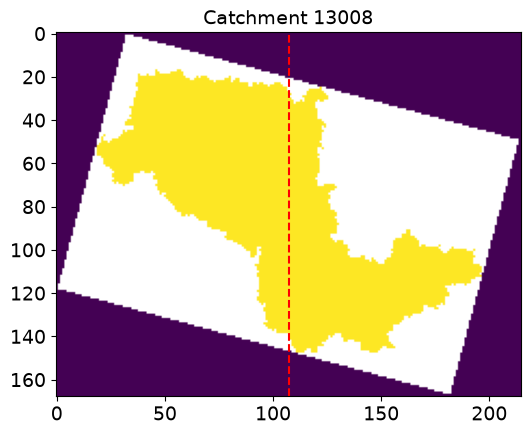

In [24]:
plt.figure(figsize=(6,6))

plt.imshow(rotated_mask_data[54057]['rotated_field'], origin='upper')

plt.axvline(
    rotated_mask_data[54057]['rotated_field'].shape[1] / 2,
    color='red',
    ls='--'
)

plt.title(f"Catchment {id}")
plt.show()

Rotating the mask again but getting rid of the excess purple border

In [37]:
rotated_mask_data = {} # build a new dict again

for id in catch_ids: # for each ID in the catchment_IDs list...

    # Rotate catchment mask
    rotated_mask = rotate(
        catchment_rainfall_data[id]['mask_2d'], # rotate the 2d mask of this ID
        angle=catchment_rainfall_data[id]['rotation_angle'], # ... by the angle stated 
        reshape=True, # and expand the box so the entire rotated thing is included
        order=0
    )

    # Rotate an array of ones to get the valid footprint
    valid_extent = rotate(
        np.ones_like(catchment_rainfall_data[id]['mask_2d']), # rotate an array of the same shape as the mask
        angle=catchment_rainfall_data[id]['rotation_angle'], #... by the same angle
        reshape=True,
        order=0
    )

    # Convert corners outside the rotated rectangle to NaN
    rotated_mask = rotated_mask.astype(float) # convert the datatype in the rotated mask into float
    rotated_mask[valid_extent == 0] = np.nan # for the elements in the rotated mask at the same index
    # as the valid_extent, where is equals 0, mask these out into NaNs 

    rotated_mask_data[id] = { # add these both to the dictionary with the key of the Id
        'rotated_field': rotated_mask,
        'valid_extent': valid_extent
    }

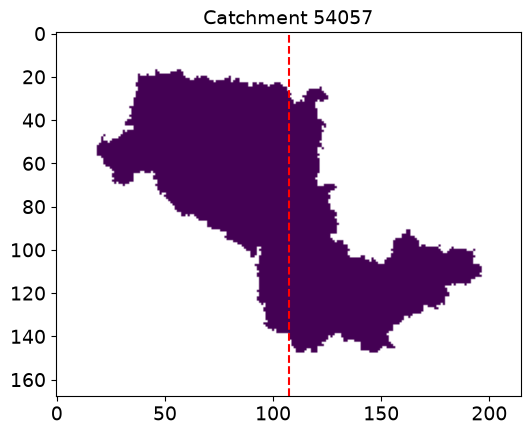

In [ ]:
# catch_id = 54057

plt.figure(figsize=(6,6))

plt.imshow( # plotting the rotated mask
    rotated_mask_data[catch_id]['rotated_field'],
    origin='upper',
    cmap='viridis'
)

plt.axvline(
    rotated_mask_data[catch_id]['rotated_field'].shape[1] / 2,
    color='red',
    ls='--'
)

plt.title(f"Catchment {catch_id}")
plt.show()

Trying to rotate the rainfall field dataframe 

In [35]:
# Trying to rotate the values df 
rotated_rainfall_data = {}

# Rotating the 2d mask:
for id in catch_ids:
    rotated_rainfall_fields= rotate(
        catchment_rainfall_data[id]['values'],
        angle = catchment_rainfall_data[id]['rotation_angle'],
        reshape = True,
        order = 0
    )

    rotated_rainfall_data[id] = {
    'rotated_rainfall_field': rotated_rainfall_fields}

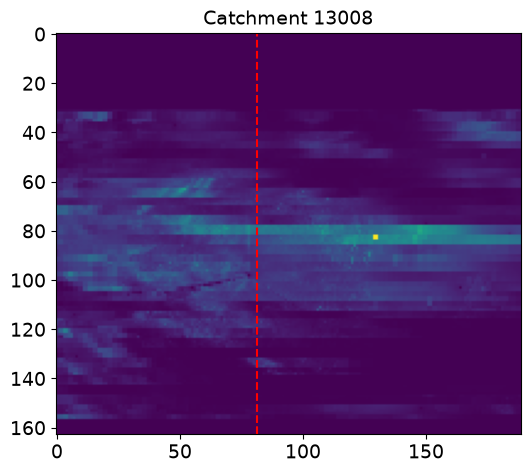

In [36]:
plt.figure(figsize=(6,6))

plt.imshow(rotated_rainfall_data[54057]['rotated_rainfall_field'][50], origin='upper')

plt.axvline(
    rotated_rainfall_data[54057]['rotated_rainfall_field'].shape[1] / 2,
    color='red',
    ls='--'
)

plt.title(f"Catchment {id}")
plt.show()

Trying to rotate again but with the new border

In [39]:
for id in catch_ids: # for each ID in the catchment_IDs list...

    # Rotate catchment mask
    rotated_mask = rotate(
        catchment_rainfall_data[id]['values'], # rotate the 2d mask of this ID
        angle=catchment_rainfall_data[id]['rotation_angle'], # ... by the angle stated 
        reshape=True, # and expand the box so the entire rotated thing is included
        order=0
    )

    # Rotate an array of ones to get the valid footprint
    valid_extent = rotate(
        np.ones_like(catchment_rainfall_data[id]['values']), # rotate an array of the same shape as the mask
        angle=catchment_rainfall_data[id]['rotation_angle'], #... by the same angle
        reshape=True,
        order=0
    )

    # Convert corners outside the rotated rectangle to NaN
    rotated_mask = rotated_mask.astype(float) # convert the datatype in the rotated mask into float
    rotated_mask[valid_extent == 0] = np.nan # for the elements in the rotated mask at the same index
    # as the valid_extent, where is equals 0, mask these out into NaNs 

    rotated_rainfall_data[id] = { # add these both to the dictionary with the key of the Id
        'rotated_rainfall_field': rotated_mask,
        'valid_extent': valid_extent
    }

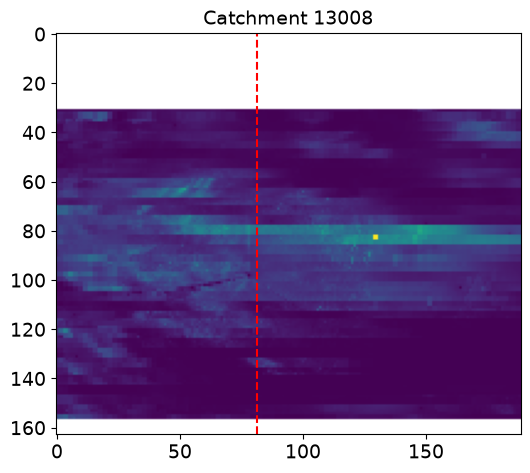

In [40]:
plt.figure(figsize=(6,6))

plt.imshow(rotated_rainfall_data[54057]['rotated_rainfall_field'][50], origin='upper')

plt.axvline(
    rotated_rainfall_data[54057]['rotated_rainfall_field'].shape[1] / 2,
    color='red',
    ls='--'
)

plt.title(f"Catchment {id}")
plt.show()

Attempting to trim the rainfall field so it only shows data for the catchment

In [ ]:
# Rotating the mask and the rainfall field at the same time:
all_rotated_data = {} # build a new dict again

for id in catch_ids: # for each ID in the catchment_IDs list...

    # Rotate catchment mask
    rotated_mask = rotate(
        catchment_rainfall_data[id]['mask_2d'], # rotate the 2d mask of this ID
        angle=catchment_rainfall_data[id]['rotation_angle'], # ... by the angle stated 
        reshape=True, # and expand the box so the entire rotated thing is included
        order=0
    )

    # Rotate the rainfall field
    rotated_rainfall = rotate(
        catchment_rainfall_data[id]['values'],
        angle=catchment_rainfall_data[id]['rotation_angle'],
        axes = (1,2),
        reshape=True,
        order=0
    )
    print(f"Catchment {id} rainfall field and mask rotated")

    # Masking out the rainfall which falls outside of the catchment:
    rotated_rainfall = rotated_rainfall.astype(float) # converting the rainfall data to floats
    rotated_rainfall = np.where(rotated_mask[None, :, :] >0, rotated_rainfall, np.nan)

    all_rotated_data[id] = { # add these both to the dictionary with the key of the Id
        'rotated_rainfall_field': rotated_rainfall,
        'rotated_catchment_mask': rotated_mask 
    }

    print(f"Catchment {id} rotated and added to dictionary \n")

Catchment 54057 rainfall field and mask rotated
Catchment 54057 rotated and added to dictionary 

Catchment 22007 rainfall field and mask rotated
Catchment 22007 rotated and added to dictionary 

Catchment 75002 rainfall field and mask rotated
Catchment 75002 rotated and added to dictionary 

Catchment 76007 rainfall field and mask rotated
Catchment 76007 rotated and added to dictionary 

Catchment 25006 rainfall field and mask rotated
Catchment 25006 rotated and added to dictionary 

Catchment 13008 rainfall field and mask rotated
Catchment 13008 rotated and added to dictionary 



In [78]:
print("Original rainfall:", catchment_rainfall_data[id]['values'].shape)
print("Rotated rainfall:", rotated_rainfall.shape)
print("Rotated mask:", rotated_mask.shape)

Original rainfall: (168, 123, 189)
Rotated rainfall: (194, 163, 189)
Rotated mask: (168, 215)


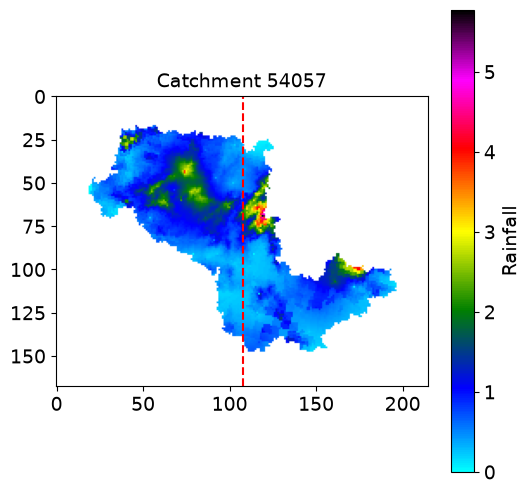

In [116]:
catch_id = 54057
timestep = 50

plt.figure(figsize=(6, 6))

plt.imshow(
    all_rotated_data[catch_id]['rotated_rainfall_field'][timestep],
    origin='upper',
    cmap = CMAP
)

plt.colorbar(label='Rainfall')

plt.axvline(
    all_rotated_data[catch_id]['rotated_rainfall_field'].shape[2] / 2,
    color='red',
    ls='--'
)

plt.title(f"Catchment {catch_id}")
plt.show()

In [114]:
# Change each of these...
SELECTED_EVENT_IDX = 4
catch_id = 25006
VMAX = 25

GIF saved → C:\Users\sopgra\UKCEH\results_trials\mp4s\05_yorkshire_dale_floods_2019_25006.gif


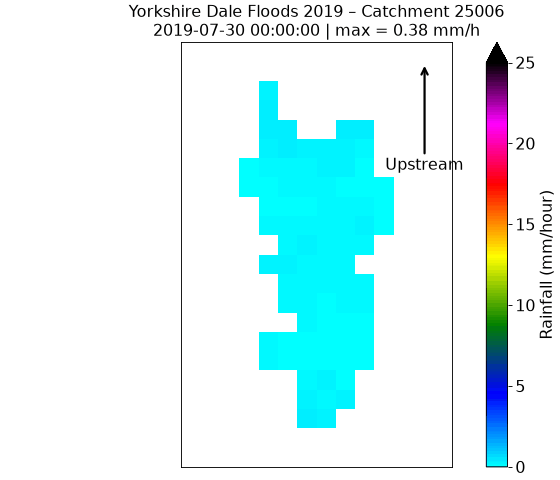

In [115]:
# ── Animation controls ────────────────────────────────────────────────────────
ANIM_EVENT_IDX = SELECTED_EVENT_IDX   # use the same event as above, or change
ANIM_INTERVAL  = 1000                  # ms per frame
ANIM_DPI       = 80                   # lower = smaller file
ANIM_VMAX      = VMAX
# ─────────────────────────────────────────────────────────────────────────────

anim_meta = EVENTS[ANIM_EVENT_IDX] # selecting the dictionary with the meta data for this event
anim_eid  = anim_meta['event_id'] # selecting the event ID

if anim_eid not in ready_events: # troubleshooting: if the data isn't there, say it isn't there...
    raise FileNotFoundError(f'CSV files for "{anim_eid}" not found in {DATA_DIR}.')

flat_df_a = catchment_rainfall_data[catch_id]['flat_df']
values_a = all_rotated_data[catch_id]['rotated_rainfall_field']
mask_a = all_rotated_data[catch_id]['rotated_catchment_mask']
# northings_a = 
# eastings_a = 

fig_a, ax_a = plt.subplots(figsize=(7, 6), constrained_layout=True)
im_a = ax_a.imshow(
    values_a[0],
    origin='upper',
    # extent=[eastings_a.min(), eastings_a.max(),
    #         northings_a.min(), northings_a.max()],
    cmap=CMAP, vmin=0, vmax=ANIM_VMAX, aspect='equal',
)
# draw_catchment_outline(ax_a, mask_a, eastings_a, northings_a)
fig_a.colorbar(im_a, ax=ax_a, label='Rainfall (mm/hour)', extend='max')
# ax_a.annotate("Upstream", xy = (0.2, 0.8), xytext = (0.2, 0.4), transform = ax_a.transAxes)
ax_a.annotate(
    "Upstream",
    xy=(0.9, 0.95),
    xytext=(0.9, 0.7),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    arrowprops={'arrowstyle': '->', 'lw': 2}
)

ax_a.set_xticks([])
ax_a.set_yticks([])

title_a = ax_a.set_title('')

def _update(frame_idx: int):
    frame = values_a[frame_idx]
    im_a.set_data(frame)
    step_t = flat_df_a.loc[frame_idx, 'time']
    title_a.set_text(
        f'{anim_meta["event_name"]} – Catchment {anim_meta["catchment_id"]}\n'
        f'{step_t} | max = {np.nanmax(frame):.2f} mm/h'
    )
    return (im_a, title_a)

ani = animation.FuncAnimation(
    fig_a, _update,
    frames=values_a.shape[0],
    interval=ANIM_INTERVAL,
    blit=False,
)

# Try MP4 first (needs ffmpeg), fall back to GIF
out_mp4 = mp4_dir / f'{anim_eid}.mp4'
out_gif = mp4_dir / f'{anim_eid}.gif'

if shutil.which('ffmpeg'):
    ani.save(str(out_mp4), writer='ffmpeg', dpi=ANIM_DPI)
    plt.close(fig_a)
    print(f'MP4 saved → {out_mp4}')
    # Display using HTML5 video in Colab
    from IPython.display import HTML
    import base64
    video_b64 = base64.b64encode(out_mp4.read_bytes()).decode()
    display(HTML(f'<video controls width="640">'
                 f'<source src="data:video/mp4;base64,{video_b64}" type="video/mp4">'
                 f'</video>'))
else:
    ani.save(str(out_gif), writer='pillow', dpi=ANIM_DPI)
    plt.close(fig_a)
    print(f'GIF saved → {out_gif}')
    display(Image(filename=str(out_gif)))

In [99]:
print(type(dict))

<class 'dict'>


In [161]:
# Getting the catchments:
